<a href="https://colab.research.google.com/github/Cohends/IT480-FA26/blob/main/Assignments/Assignment2_TransferLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2: Transfer Learning Across Two Datasets

**Name:** *Dylan Cohen*

**Prerequisite:** Transfer Learning lecture (frozen feature extraction)

This assignment uses frozen transfer learning, exactly what was covered in lecture: load a pretrained base, freeze it, add a new head, train only that. You'll do this twice, on two different datasets, and compare the results.

Data loading is provided for you below. Everything after that, building the model, training, evaluating, and reflecting, is yours to write, following the general instructions in each section.

**Submission:** GitHub repo URL and this notebook's URL on Canvas.

## Setup — Imports

In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

---
# Part 1: Fire/Smoke Detection

## 1A — Load the Data

In [3]:
!pip install legacy-cgi --quiet
!pip install opendatasets --quiet

import opendatasets as od
od.download("https://www.kaggle.com/datasets/phylake1337/fire-dataset")

for root, dirs, files in os.walk("fire-dataset"):
    print(root, "->", dirs[:5], f"({len(files)} files)")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: dylanscohen
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/phylake1337/fire-dataset


100%|██████████| 387M/387M [00:06<00:00, 59.7MB/s]



fire-dataset -> ['fire_dataset'] (0 files)
fire-dataset/fire_dataset -> ['fire_images', 'non_fire_images'] (0 files)
fire-dataset/fire_dataset/fire_images -> [] (755 files)
fire-dataset/fire_dataset/non_fire_images -> [] (244 files)


In [4]:
data_dir_fire = "fire-dataset/fire_dataset"

img_size = (224, 224)
batch_size = 32

train_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_fire = tf.data.experimental.cardinality(val_test_raw_fire)
test_raw_fire = val_test_raw_fire.take(val_test_batches_fire // 2)
val_raw_fire = val_test_raw_fire.skip(val_test_batches_fire // 2)

class_names_fire = train_raw_fire.class_names
print("Class names:", class_names_fire)

Found 999 files belonging to 2 classes.
Using 700 files for training.
Found 999 files belonging to 2 classes.
Using 299 files for validation.
Class names: ['fire_images', 'non_fire_images']


## 1B — Inspect the Data

Before doing anything else, take a real look at what you loaded. How many images does each class have? Is there anything about the data itself that might affect how you should split it, or how you should interpret your model's results later?

Write whatever code you need to answer this for yourself.

Fire images: 755
Non-fire images: 244
Total images: 999

Training batches: 22
Validation/test batches: 10


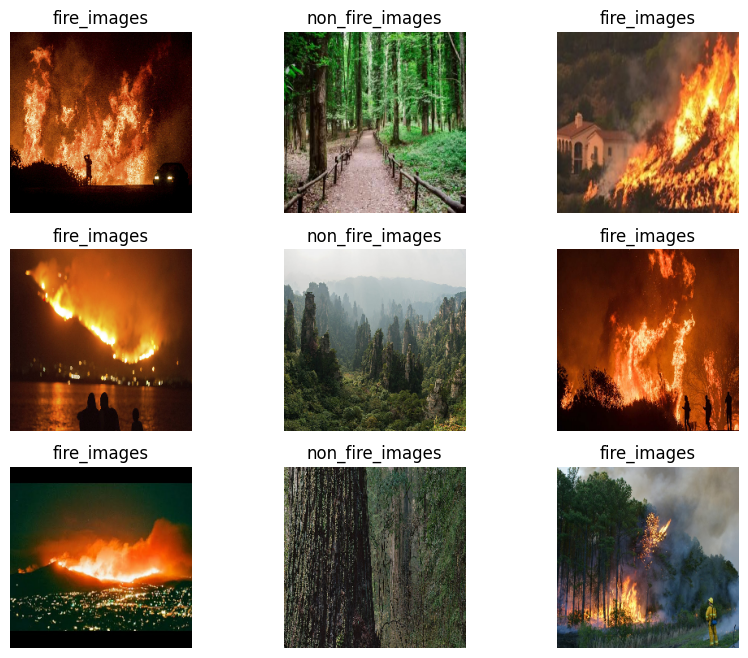

In [5]:
# Your exploration here

from pathlib import Path

fire_dir = Path("fire-dataset/fire_dataset/fire_images")
non_fire_dir = Path("fire-dataset/fire_dataset/non_fire_images")

fire_count = len(list(fire_dir.glob("*")))
non_fire_count = len(list(non_fire_dir.glob("*")))

print("Fire images:", fire_count)
print("Non-fire images:", non_fire_count)
print("Total images:", fire_count + non_fire_count)

print("\nTraining batches:", tf.data.experimental.cardinality(train_raw_fire).numpy())
print("Validation/test batches:", tf.data.experimental.cardinality(val_test_raw_fire).numpy())

# Optional: display several examples with their labels
plt.figure(figsize=(10, 8))
for images, labels in train_raw_fire.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names_fire[labels[i]])
        plt.axis("off")

*What did you notice about this dataset? Does it change how you'll approach the next steps?*

The dataset contains 999 images total: 755 fire images and 244 non-fire images. This means the classes are imbalanced, with fire images making up most of the dataset. The provided split uses 700 images for training and 299 images for validation/testing, but accuracy alone may be misleading because a model could benefit from the larger fire class. I will also use a confusion matrix and pay close attention to false negatives, since incorrectly labeling a real fire as non-fire could be dangerous. The dataset is relatively small, so using frozen transfer learning with MobileNetV2 is appropriate instead of training a large CNN from scratch.
colab.research.google

## 1C — Build a Frozen Transfer Learning Model

Using MobileNetV2 as your pretrained base:
- Freeze the base model entirely
- Add a new output layer appropriate for this task (think about how many classes you're predicting, and what that means for your output layer's size, activation, and loss function)
- Remember the pattern from lecture for how the base model should be called

Preprocess your data (`train_raw_fire`, `val_raw_fire`, `test_raw_fire`) using MobileNetV2's expected preprocessing before building your model.

In [6]:
# Preprocess the data here

AUTOTUNE = tf.data.AUTOTUNE

train_fire = train_raw_fire.map(
    lambda images, labels: (preprocess_input(images), labels),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

val_fire = val_raw_fire.map(
    lambda images, labels: (preprocess_input(images), labels),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

test_fire = test_raw_fire.map(
    lambda images, labels: (preprocess_input(images), labels),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

In [7]:
# Build your model here

base_model_fire = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model_fire.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))

# training=False keeps MobileNetV2 frozen during training
x = base_model_fire(inputs, training=False)

x = GlobalAveragePooling2D()(x)

outputs = Dense(1, activation="sigmoid")(x)

model_fire = Model(inputs, outputs)

model_fire.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
# Compile your model here

model_fire.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

## 1D — Train and Evaluate

In [9]:
# Train your model here

early_stop_fire = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_fire = model_fire.fit(
    train_fire,
    validation_data=val_fire,
    epochs=5,
    callbacks=[early_stop_fire]
)

Epoch 1/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - accuracy: 0.8700 - loss: 0.2921 - val_accuracy: 0.9424 - val_loss: 0.1649
Epoch 2/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 587ms/step - accuracy: 0.9686 - loss: 0.1184 - val_accuracy: 0.9568 - val_loss: 0.1071
Epoch 3/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 529ms/step - accuracy: 0.9771 - loss: 0.0849 - val_accuracy: 0.9784 - val_loss: 0.0728
Epoch 4/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 23s 647ms/step - accuracy: 0.9857 - loss: 0.0684 - val_accuracy: 0.9712 - val_loss: 0.0753
Epoch 5/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 544ms/step - accuracy: 0.9857 - loss: 0.0594 - val_accuracy: 0.9856 - val_loss: 0.0599


In [10]:
# Report validation and test accuracy here

val_loss_fire, val_acc_fire = model_fire.evaluate(
    val_fire,
    verbose=0
)

test_loss_fire, test_acc_fire = model_fire.evaluate(
    test_fire,
    verbose=0
)

print(f"Validation loss: {val_loss_fire:.4f}")
print(f"Validation accuracy: {val_acc_fire:.4%}")

print(f"\nTest loss: {test_loss_fire:.4f}")
print(f"Test accuracy: {test_acc_fire:.4%}")

Validation loss: 0.0728
Validation accuracy: 97.1223%

Test loss: 0.0608
Test accuracy: 98.1250%


## 1E — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** In this context, is a false negative (missing a real fire) or a false positive (a false alarm) more costly? How might that change the decision threshold you'd actually use in practice, rather than the default 0.5?

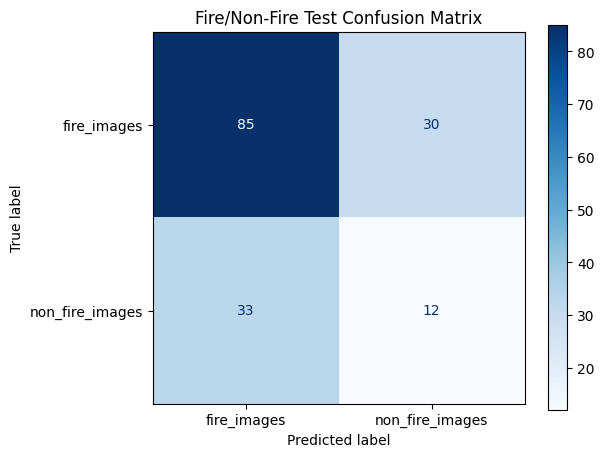

Rows = actual class; columns = predicted class.
Class 0 = fire_images; Class 1 = non_fire_images.


In [11]:
# Build your confusion matrix here

# Collect the true labels and model predictions from the test dataset
y_true_fire = np.concatenate([
    labels.numpy()
    for images, labels in test_fire
])

y_prob_fire = np.concatenate([
    model_fire.predict(images, verbose=0).flatten()
    for images, labels in test_fire
])

# Default binary decision threshold
threshold = 0.5
y_pred_fire = (y_prob_fire >= threshold).astype(int)

# Build and display the confusion matrix
cm_fire = confusion_matrix(y_true_fire, y_pred_fire)

display_fire = ConfusionMatrixDisplay(
    confusion_matrix=cm_fire,
    display_labels=class_names_fire
)

fig, ax = plt.subplots(figsize=(6, 5))
display_fire.plot(cmap="Blues", values_format="d", ax=ax)
plt.title("Fire/Non-Fire Test Confusion Matrix")
plt.show()

print("Rows = actual class; columns = predicted class.")
print("Class 0 = fire_images; Class 1 = non_fire_images.")

*Your answer:*

In a fire-detection system, a false negative is usually more costly than a false positive. A false negative means the model predicts “non-fire” when a real fire is present, which could delay an alert and increase the risk of property damage, injury, or loss of life. A false positive may cause an unnecessary alarm or manual review, but that cost is generally safer and less severe than missing a real fire. Therefore, in a real-world safety-focused system, I would use a lower decision threshold than the default 0.5. For example, a threshold of 0.3 would label an image as non-fire only when the model is sufficiently confident; it would tend to classify more uncertain cases as fire, reducing missed fires while increasing false alarms. The threshold should ultimately be selected using validation data and the real operational cost of false alarms versus missed fires.
colab.research.google





---
# Part 2: Satellite Land-Use Classification (EuroSAT)

## 2A — Load the Data

In [13]:
!wget -q "https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip?download=1" -O EuroSAT_RGB.zip
!unzip -q EuroSAT_RGB.zip -d eurosat_data

data_dir_sat = "eurosat_data/EuroSAT_RGB"
print(os.listdir(data_dir_sat))

['Highway', 'River', 'HerbaceousVegetation', 'Industrial', 'Pasture', 'AnnualCrop', 'SeaLake', 'PermanentCrop', 'Forest', 'Residential']


In [14]:
train_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_sat = tf.data.experimental.cardinality(val_test_raw_sat)
test_raw_sat = val_test_raw_sat.take(val_test_batches_sat // 2)
val_raw_sat = val_test_raw_sat.skip(val_test_batches_sat // 2)

class_names_sat = train_raw_sat.class_names
print("Class names:", class_names_sat)

Found 27000 files belonging to 10 classes.
Using 18900 files for training.
Found 27000 files belonging to 10 classes.
Using 8100 files for validation.
Class names: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## 2B — Build a Frozen Transfer Learning Model

Same overall pattern as Part 1, but look closely at what's different about this task before you build your output layer, activation, and loss function.

Preprocess `train_raw_sat`, `val_raw_sat`, and `test_raw_sat` first.

In [15]:
val_test_batches_sat = tf.data.experimental.cardinality(val_test_raw_sat)

test_raw_sat = val_test_raw_sat.take(val_test_batches_sat // 2)
val_raw_sat = val_test_raw_sat.skip(val_test_batches_sat // 2)

class_names_sat = train_raw_sat.class_names

print("Class names:", class_names_sat)
print("Training batches:", tf.data.experimental.cardinality(train_raw_sat).numpy())
print("Validation/test batches:", val_test_batches_sat.numpy())

Class names: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Training batches: 591
Validation/test batches: 254


In [16]:
# Preprocess the data here

AUTOTUNE = tf.data.AUTOTUNE

train_sat = train_raw_sat.map(
    lambda images, labels: (preprocess_input(images), labels),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

val_sat = val_raw_sat.map(
    lambda images, labels: (preprocess_input(images), labels),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

test_sat = test_raw_sat.map(
    lambda images, labels: (preprocess_input(images), labels),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

In [17]:
# Build your model here

base_model_sat = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze all pretrained MobileNetV2 layers
base_model_sat.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))

# Keep BatchNormalization layers in inference mode
x = base_model_sat(inputs, training=False)

x = GlobalAveragePooling2D()(x)

# Ten output probabilities: one for each EuroSAT category
outputs = Dense(10, activation="softmax")(x)

model_sat = Model(inputs, outputs)

model_sat.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [18]:
# Compile your model here

model_sat.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## 2C — Train and Evaluate

In [19]:
# Train your model here

early_stop_sat = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_sat = model_sat.fit(
    train_sat,
    validation_data=val_sat,
    epochs=5,
    callbacks=[early_stop_sat]
)

Epoch 1/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 58s 85ms/step - accuracy: 0.8795 - loss: 0.3715 - val_accuracy: 0.9319 - val_loss: 0.2152
Epoch 2/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 52s 41ms/step - accuracy: 0.9336 - loss: 0.1947 - val_accuracy: 0.9393 - val_loss: 0.1891
Epoch 3/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 24s 40ms/step - accuracy: 0.9478 - loss: 0.1587 - val_accuracy: 0.9400 - val_loss: 0.1831
Epoch 4/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 24s 40ms/step - accuracy: 0.9532 - loss: 0.1378 - val_accuracy: 0.9395 - val_loss: 0.1817
Epoch 5/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 28s 47ms/step - accuracy: 0.9604 - loss: 0.1213 - val_accuracy: 0.9400 - val_loss: 0.1748


In [20]:
# Report validation and test accuracy here

val_loss_sat, val_acc_sat = model_sat.evaluate(
    val_sat,
    verbose=0
)

test_loss_sat, test_acc_sat = model_sat.evaluate(
    test_sat,
    verbose=0
)

print(f"Validation loss: {val_loss_sat:.4f}")
print(f"Validation accuracy: {val_acc_sat:.4%}")

print(f"\nTest loss: {test_loss_sat:.4f}")
print(f"Test accuracy: {test_acc_sat:.4%}")

Validation loss: 0.1783
Validation accuracy: 93.8801%

Test loss: 0.1772
Test accuracy: 94.0699%


## 2D — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** Which land-use classes get confused most often? Does that make visual sense to you?

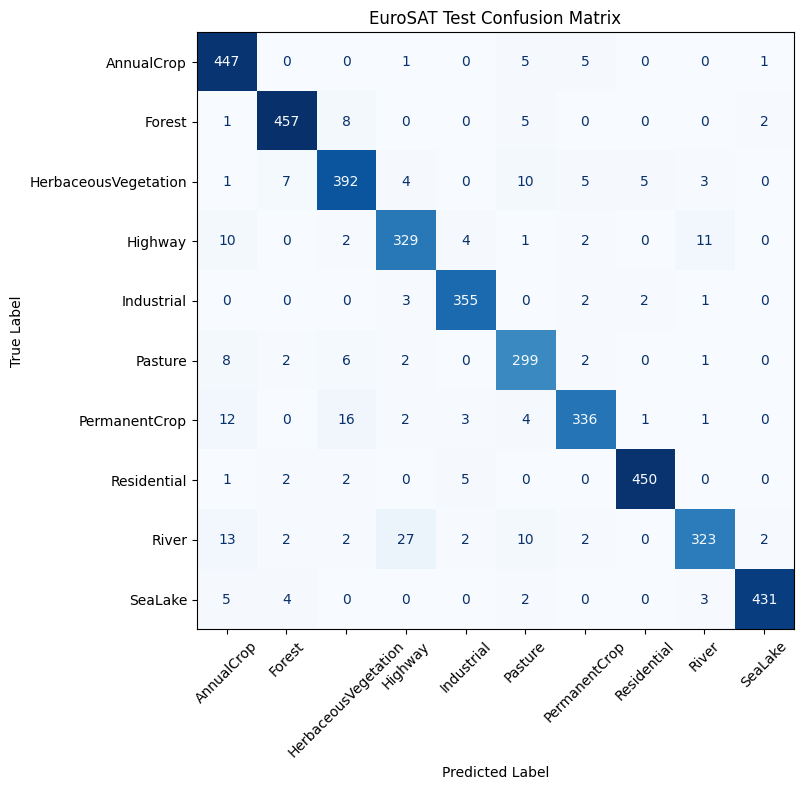

Accuracy from confusion matrix: 0.9397145669291339

Confusion matrix:
[[447   0   0   1   0   5   5   0   0   1]
 [  1 457   8   0   0   5   0   0   0   2]
 [  1   7 392   4   0  10   5   5   3   0]
 [ 10   0   2 329   4   1   2   0  11   0]
 [  0   0   0   3 355   0   2   2   1   0]
 [  8   2   6   2   0 299   2   0   1   0]
 [ 12   0  16   2   3   4 336   1   1   0]
 [  1   2   2   0   5   0   0 450   0   0]
 [ 13   2   2  27   2  10   2   0 323   2]
 [  5   4   0   0   0   2   0   0   3 431]]


In [24]:
# Build your confusion matrix here

y_true_sat = []
y_pred_sat = []

for images, labels in test_sat:
    probabilities = model_sat.predict(images, verbose=0)
    predictions = np.argmax(probabilities, axis=1)

    y_true_sat.extend(labels.numpy())
    y_pred_sat.extend(predictions)

y_true_sat = np.array(y_true_sat)
y_pred_sat = np.array(y_pred_sat)

cm_sat = confusion_matrix(y_true_sat, y_pred_sat)

fig, ax = plt.subplots(figsize=(10, 8))

ConfusionMatrixDisplay(
    confusion_matrix=cm_sat,
    display_labels=class_names_sat
).plot(
    cmap="Blues",
    xticks_rotation=45,
    values_format="d",
    ax=ax,
    colorbar=False
)

plt.title("EuroSAT Test Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

print("Accuracy from confusion matrix:", np.trace(cm_sat) / cm_sat.sum())
print("\nConfusion matrix:")
print(cm_sat)

*Your answer:*

The land-use classes that were confused most often were River and Highway. In particular, 27 images that were actually River were predicted as Highway. This makes visual sense because both categories can have similar colors, textures, and spatial patterns when viewed from above in satellite images. For example, agricultural classes such as AnnualCrop, PermanentCrop, and Pasture can all contain green or brown vegetation and field-like patterns, while Residential and Industrial areas can both contain dense buildings, roads, and gray surfaces. Overall, the matrix has a strong diagonal, which matches the model’s 94.07% test accuracy.
colab.research.google


---
# Part 3: Compare the Two Domains

Fill in your own results:

| | Fire/Smoke | EuroSAT |
|---|---|---|
| Validation Accuracy |97.12%|93.88%|
| Test Accuracy |98.13%|94.07%|

**Answer:**
1. MobileNetV2 was originally trained on ImageNet, ordinary ground-level photos of everyday objects. Which of your two datasets do you think is the closer match to that original training, and which is the bigger mismatch? Use your actual results as evidence.
2. For each dataset, do you think there's room for improvement if you could adjust part of the pretrained model itself, rather than just the new layer on top? Would you expect that to matter more for one dataset than the other? Why?

*Your answers:*

**1.** The Fire/Smoke dataset is closer to ImageNet because both use regular ground-level images. EuroSAT is the bigger mismatch because it uses satellite images from above. This matches the results: Fire/Smoke had a higher test accuracy of 98.13%, while EuroSAT had 94.07%.

**2.** Both models could improve with fine-tuning, meaning unfreezing some upper MobileNetV2 layers and training them with a small learning rate. Fine-tuning would likely help EuroSAT more because satellite images are more different from the everyday images MobileNetV2 learned from ImageNet.


---
# Part 4: Reflection

Answer in 4 to 6 sentences:

1. Did anything about the Fire dataset's composition affect how you approached splitting or evaluating it? Explain.
2. What's the actual difference between the output layer, activation, and loss function you used in Part 1 versus Part 2? Why does that difference exist?
3. Based on your results, does a pretrained model's usefulness depend only on how good the model is, or also on how well its original training matches your task? Explain using your own two results as evidence.

*Your answers:*

The Fire dataset was imbalanced, with 755 fire images and only 244 non-fire images. Because of this, accuracy alone could be misleading, so I also used a confusion matrix and focused on the risk of false negatives. Part 1 used one sigmoid output neuron with binary cross-entropy because it had two classes, while Part 2 used 10 softmax outputs with sparse categorical cross-entropy because EuroSAT had 10 classes. The pretrained model’s usefulness depends on both the model and how closely the original training data matches the new task. Fire/Smoke was closer to ImageNet-style photos and achieved 98.13% test accuracy, while the more different satellite-image EuroSAT dataset achieved 94.07%.


---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.